<a href="https://colab.research.google.com/github/SudhanshuSharma01-open/ai-image-detector/blob/main/AI_Generated_Image_Detection_using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdjubairalsadid/realvsfakefull")

print("Path to dataset files:", path)

100%|██████████| 3.98G/3.98G [00:31<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mdjubairalsadid/realvsfakefull/versions/1


In [ ]:
import os

print(os.listdir(path))

['dataset full']


In [ ]:
for folder in os.listdir(path):
    print(folder, ":", os.listdir(os.path.join(path, folder))[:5])

dataset full : ['real', 'fake']


In [ ]:
import os

print("Main folder:")
print(os.listdir(path))

Main folder:
['dataset full']


In [ ]:
for folder in os.listdir(path):
    print(folder, "->", os.listdir(os.path.join(path, folder))[:10])

dataset full -> ['real', 'fake']


In [ ]:
import os

base_path = os.path.join(path, "dataset full")

real_path = os.path.join(base_path, "real")
fake_path = os.path.join(base_path, "fake")

print("Real path:", real_path)
print("Fake path:", fake_path)

Real path: /root/.cache/kagglehub/datasets/mdjubairalsadid/realvsfakefull/versions/1/dataset full/real
Fake path: /root/.cache/kagglehub/datasets/mdjubairalsadid/realvsfakefull/versions/1/dataset full/fake


In [ ]:
from sklearn.model_selection import train_test_split
import shutil

# Create folders
os.makedirs("/content/data/train/real", exist_ok=True)
os.makedirs("/content/data/train/fake", exist_ok=True)
os.makedirs("/content/data/test/real", exist_ok=True)
os.makedirs("/content/data/test/fake", exist_ok=True)

def split_data(src, train_dst, test_dst):
    files = os.listdir(src)
    train, test = train_test_split(files, test_size=0.2, random_state=42)

    for f in train:
        shutil.copy(os.path.join(src, f), os.path.join(train_dst, f))
    for f in test:
        shutil.copy(os.path.join(src, f), os.path.join(test_dst, f))

# Split both classes
split_data(real_path, "/content/data/train/real", "/content/data/test/real")
split_data(fake_path, "/content/data/train/fake", "/content/data/test/fake")

train_dir = "/content/data/train"
test_dir = "/content/data/test"

print("✅ Dataset Ready!")

✅ Dataset Ready!


In [ ]:
import tensorflow as tf

img_size = (128,128)

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=32
)

Found 1161 files belonging to 2 classes.
Found 288 files belonging to 2 classes.


In [ ]:
train_data = train_data.map(lambda x,y: (x/255.0, y))
test_data = test_data.map(lambda x,y: (x/255.0, y))

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5203 - loss: 0.7645 - val_accuracy: 0.6042 - val_loss: 0.6405
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6541 - loss: 0.6487 - val_accuracy: 0.7118 - val_loss: 0.5835
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6833 - loss: 0.5953 - val_accuracy: 0.7153 - val_loss: 0.5639
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7057 - loss: 0.5777 - val_accuracy: 0.7465 - val_loss: 0.5282
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7087 - loss: 0.5512 - val_accuracy: 0.7326 - val_loss: 0.5583


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving text-to-image-AI-1.jpg to text-to-image-AI-1.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


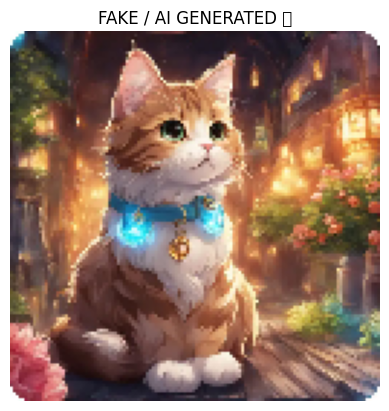

Prediction value: 0.5724503


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

# Show image
plt.imshow(img)
plt.axis('off')

# Result
if prediction[0][0] > 0.5:
    result = "FAKE / AI GENERATED ❌"
else:
    result = "REAL IMAGE ✅"

plt.title(result)
plt.show()

print("Prediction value:", prediction[0][0])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving vasantholsavam-to-add-more-colour-to-thiruvananthapuram-city-from-dec-23.avif to vasantholsavam-to-add-more-colour-to-thiruvananthapuram-city-from-dec-23.avif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


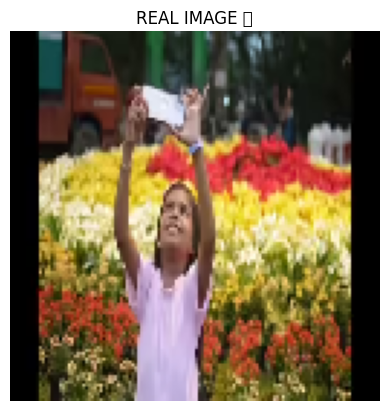

Prediction value: 0.31200707


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

# Show image
plt.imshow(img)
plt.axis('off')

# Result
if prediction[0][0] > 0.5:
    result = "FAKE / AI GENERATED ❌"
else:
    result = "REAL IMAGE ✅"

plt.title(result)
plt.show()

print("Prediction value:", prediction[0][0])

In [ ]:
confidence = prediction[0][0]

if confidence > 0.5:
    print(f"FAKE IMAGE ({confidence*100:.2f}% confidence)")
else:
    print(f"REAL IMAGE ({(1-confidence)*100:.2f}% confidence)")

REAL IMAGE (68.80% confidence)


# Instead of basic CNN → use MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
train_data = train_data.map(lambda x, y: (data_augmentation(x), y))

In [ ]:
history = model.fit(
    train_data,
    epochs=8,
    validation_data=test_data
)

Epoch 1/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6282 - loss: 0.7801 - val_accuracy: 0.7812 - val_loss: 0.4707
Epoch 2/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7917 - loss: 0.4587 - val_accuracy: 0.7778 - val_loss: 0.4969
Epoch 3/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8068 - loss: 0.4197 - val_accuracy: 0.7986 - val_loss: 0.4781
Epoch 4/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.7975 - loss: 0.4269 - val_accuracy: 0.7500 - val_loss: 0.5145
Epoch 5/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8183 - loss: 0.3995 - val_accuracy: 0.8021 - val_loss: 0.4747
Epoch 6/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8563 - loss: 0.3510 - val_accuracy: 0.7500 - val_loss: 0.5508
Epoch 7/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8393 - loss: 0.3645 - val_accuracy: 0.7882 - val_loss: 0.4901
Epoch 8/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8939 - loss: 0.2856 - val_accuracy: 0.8090 - val_loss: 0.4901


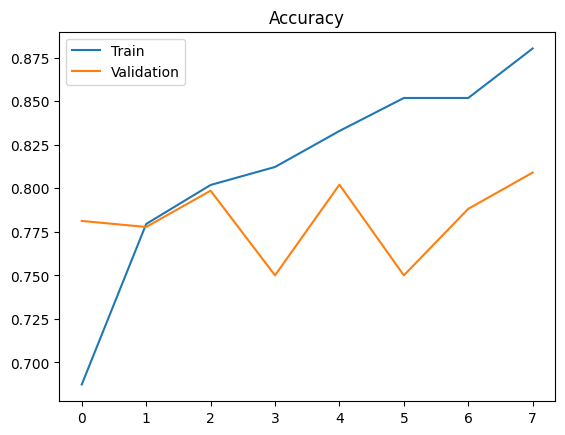

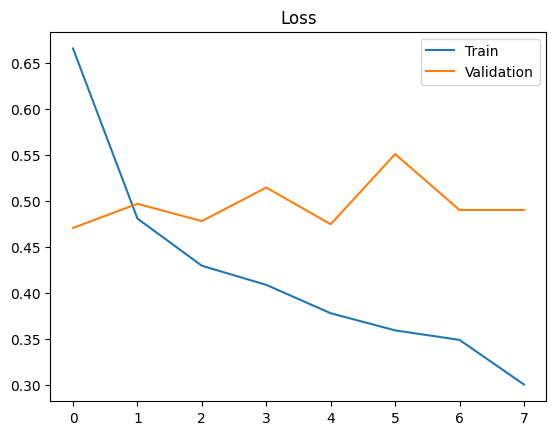

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Confusion Matrix:
 [[131  15]
 [ 40 102]]

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       146
           1       0.87      0.72      0.79       142

    accuracy                           0.81       288
   macro avg       0.82      0.81      0.81       288
weighted avg       0.82      0.81      0.81       288



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving text-to-image-AI-1.jpg to text-to-image-AI-1 (2).jpg


In [ ]:
img_path = list(uploaded.keys())[0]
print(img_path)

text-to-image-AI-1 (2).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


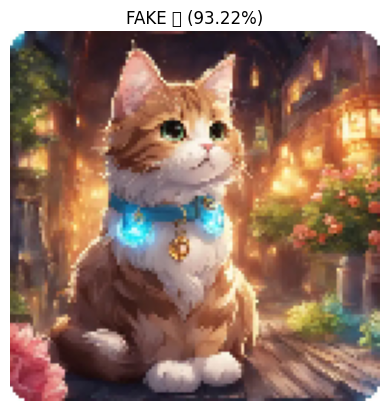

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis('off')

if prediction > 0.5:
    label = "FAKE ❌"
    confidence = prediction * 100
else:
    label = "REAL ✅"
    confidence = (1 - prediction) * 100

plt.title(f"{label} ({confidence:.2f}%)")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.jpeg to images (1).jpeg


In [ ]:
img_path = list(uploaded.keys())[0]
print(img_path)

images (1).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


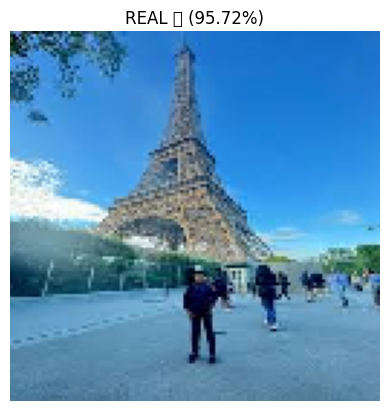

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis('off')

if prediction > 0.5:
    label = "FAKE ❌"
    confidence = prediction * 100
else:
    label = "REAL ✅"
    confidence = (1 - prediction) * 100

plt.title(f"{label} ({confidence:.2f}%)")
plt.show()

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 149.1 MB/s eta 0:00:00


In [ ]:
!mkdir ai-image-detector
%cd ai-image-detector

/content/ai-image-detector


In [ ]:
%%writefile app.py
# paste your code here

Writing app.py


In [ ]:
!ls

app.py


In [ ]:
!pip install streamlit

In [ ]:
!pip install pyngrok

In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
!ngrok config add-authtoken 3COoe5ynWVLaKkW5W7FcOhy3U3n_5Ma99jMKSwc83UyWRsJpC

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://utopia-whimsical-tux.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!ls /content/ai-image-detector

app.py


In [ ]:
model.save("ai_detector.h5")

In [ ]:
from google.colab import files
files.download("ai_detector.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model = tf.keras.models.load_model("ai_detector.h5")

In [89]:
!ls /content/ai-image-detector

ai_detector.h5	app.py


In [90]:
!streamlit run app.py &>/dev/null &

In [91]:
from google.colab import files
files.download("ai_detector.h5")
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
model.save("ai_detector.keras")

In [93]:
from google.colab import files
files.download("ai_detector.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
model.save_weights("model.weights.h5")

In [96]:
from google.colab import files
files.download("model.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://utopia-whimsical-tux.ngrok-free.dev" -> "http://localhost:8501"
